# 03 — Forecast and Position Analytics
**ARCM: Adaptive Rate Curve Model** | Liyuan Zhang

Explores the LSTM multi-horizon forecast and position-level P&L, risk metrics,
and scenario analysis for CUSIP 912797UE5.

**Prerequisite:** Full pipeline stack:
```
python pipeline.py
python regime.py
python dynamics.py
python forecast.py --epochs 200
python position.py
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR       = Path('../arcm/outputs/powerbi')
PURCHASE_PRICE = 96.439575
PURCHASE_YIELD = 3.622
PURCHASE_DATE  = pd.Timestamp('2026-04-17')

## 1. Load outputs

In [2]:
fcast_dist = pd.read_csv(DATA_DIR / 'forecast_distribution.csv', parse_dates=['date'])
fcast_cur  = pd.read_csv(DATA_DIR / 'forecast_current.csv')
history    = pd.read_csv(DATA_DIR / 'training_history.csv')
report     = pd.read_csv(DATA_DIR / 'position_report.csv',       parse_dates=['date'])
scenarios  = pd.read_csv(DATA_DIR / 'scenario_analysis.csv')
pa         = pd.read_csv(DATA_DIR / 'position_analytics.csv')

print(f"Forecast distribution : {len(fcast_dist)} rows")
print(f"Position report       : {len(report)} rows")
fcast_cur[['q10','q50','q74']]

Forecast distribution : 503 rows
Position report       : 6 rows


,q10,q50,q74
0,2.49179,3.053973,3.340099


## 2. Training convergence

Multi-horizon training (21/63/126/252d simultaneously) gives ~40x more
training signal vs single-horizon. Best val loss is epoch 1 — a known
limitation of the 2800-row post-ZLB dataset. Improves as data accumulates.

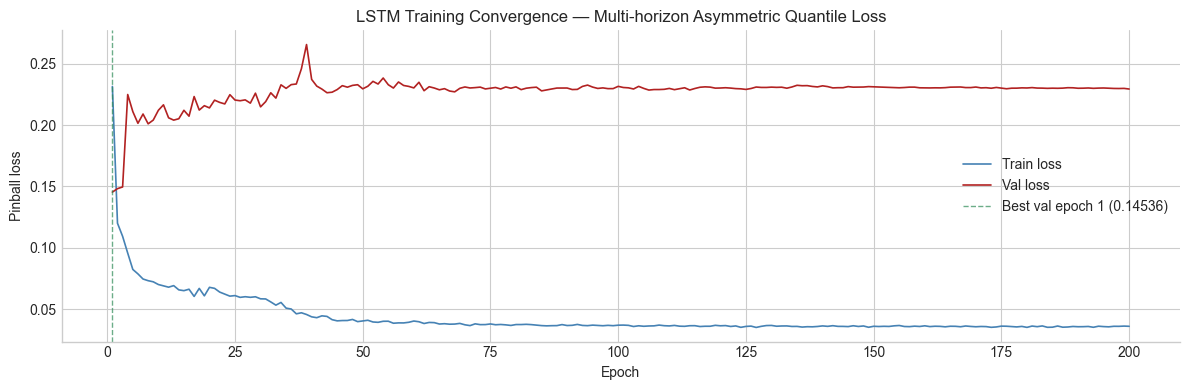

Best val loss : 0.14536 at epoch 1
Final train   : 0.03593
Train/val gap : 0.2x


In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history['epoch'], history['train_loss'],
        label='Train loss', color='steelblue', linewidth=1.2)
ax.plot(history['epoch'], history['val_loss'],
        label='Val loss', color='firebrick', linewidth=1.2)

best_epoch = int(history.loc[history['val_loss'].idxmin(), 'epoch'])
best_val   = history['val_loss'].min()
ax.axvline(best_epoch, color='seagreen', linewidth=1, linestyle='--',
           alpha=0.7, label=f'Best val epoch {best_epoch} ({best_val:.5f})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Pinball loss')
ax.set_title('LSTM Training Convergence — Multi-horizon Asymmetric Quantile Loss',
             fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best val loss : {best_val:.5f} at epoch {best_epoch}")
print(f"Final train   : {history['train_loss'].iloc[-1]:.5f}")
print(f"Train/val gap : {history['train_loss'].iloc[-1] / best_val:.1f}x")

## 3. Out-of-sample forecast distribution vs actuals

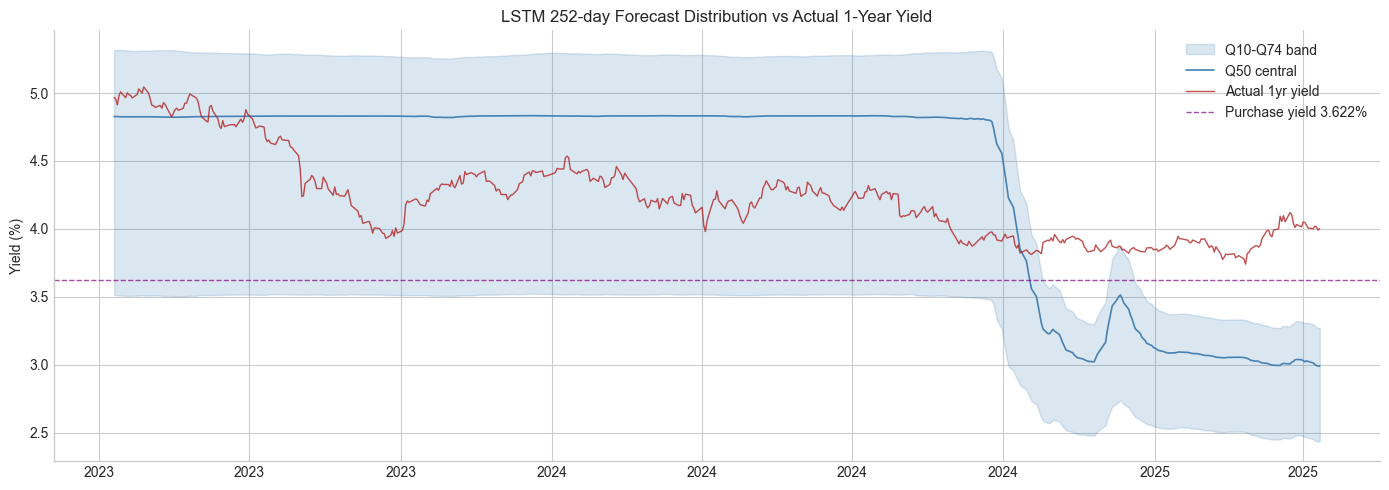

Actual in Q10-Q74 band : 76.9%
Avg interval width     : 1.557%


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(fcast_dist['date'], fcast_dist['q10'], fcast_dist['q74'],
                alpha=0.2, color='steelblue', label='Q10-Q74 band')
ax.plot(fcast_dist['date'], fcast_dist['q50'],
        color='steelblue', linewidth=1.2, label='Q50 central')
ax.plot(fcast_dist['date'], fcast_dist['actual_y1y'],
        color='firebrick', linewidth=1.0, alpha=0.8, label='Actual 1yr yield')
ax.axhline(PURCHASE_YIELD, color='purple', linewidth=1, linestyle='--',
           alpha=0.7, label=f'Purchase yield {PURCHASE_YIELD}%')

ax.set_title('LSTM 252-day Forecast Distribution vs Actual 1-Year Yield', fontsize=12)
ax.set_ylabel('Yield (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

if 'actual_in_band' in fcast_dist.columns:
    print(f"Actual in Q10-Q74 band : {fcast_dist['actual_in_band'].mean():.1%}")
if 'interval_width' in fcast_dist.columns:
    print(f"Avg interval width     : {fcast_dist['interval_width'].mean():.3f}%")

## 4. Current forecast — all horizons

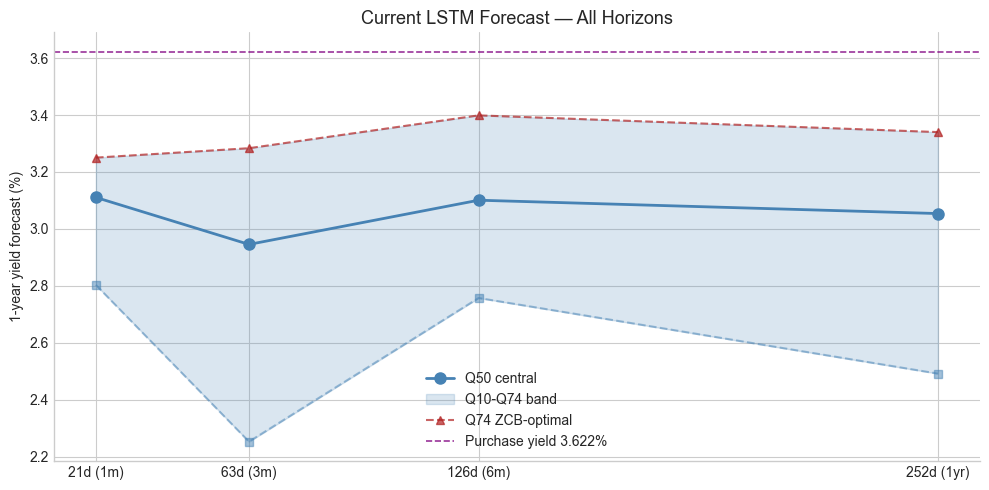


  Horizon          Q10     Q50     Q74
  ─────────────────────────────────────
  21            2.803%   3.111%   3.250%
  63            2.253%   2.946%   3.284%
  126           2.757%   3.101%   3.399%
  252           2.492%   3.054%   3.340%


In [5]:
horizons = [21, 63, 126, 252]
q10_vals = [float(fcast_cur[f'h{h}_q10'].iloc[0]) for h in horizons]
q50_vals = [float(fcast_cur[f'h{h}_q50'].iloc[0]) for h in horizons]
q74_vals = [float(fcast_cur[f'h{h}_q74'].iloc[0]) for h in horizons]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(horizons, q50_vals, 'o-', color='steelblue', linewidth=2,
        markersize=8, label='Q50 central', zorder=5)
ax.fill_between(horizons, q10_vals, q74_vals,
                alpha=0.2, color='steelblue', label='Q10-Q74 band')
ax.plot(horizons, q10_vals, 's--', color='steelblue', alpha=0.5, markersize=6)
ax.plot(horizons, q74_vals, '^--', color='firebrick', alpha=0.7,
        markersize=6, label='Q74 ZCB-optimal')
ax.axhline(PURCHASE_YIELD, color='purple', linewidth=1.2, linestyle='--',
           alpha=0.8, label=f'Purchase yield {PURCHASE_YIELD}%')

ax.set_xticks(horizons)
ax.set_xticklabels(['21d (1m)', '63d (3m)', '126d (6m)', '252d (1yr)'])
ax.set_ylabel('1-year yield forecast (%)')
ax.set_title('Current LSTM Forecast — All Horizons', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n  {'Horizon':<12} {'Q10':>7} {'Q50':>7} {'Q74':>7}")
print(f"  {'─'*37}")
for h, q10, q50, q74 in zip(horizons, q10_vals, q50_vals, q74_vals):
    print(f"  {h:<12} {q10:>6.3f}%  {q50:>6.3f}%  {q74:>6.3f}%")

## 5. Position P&L since purchase

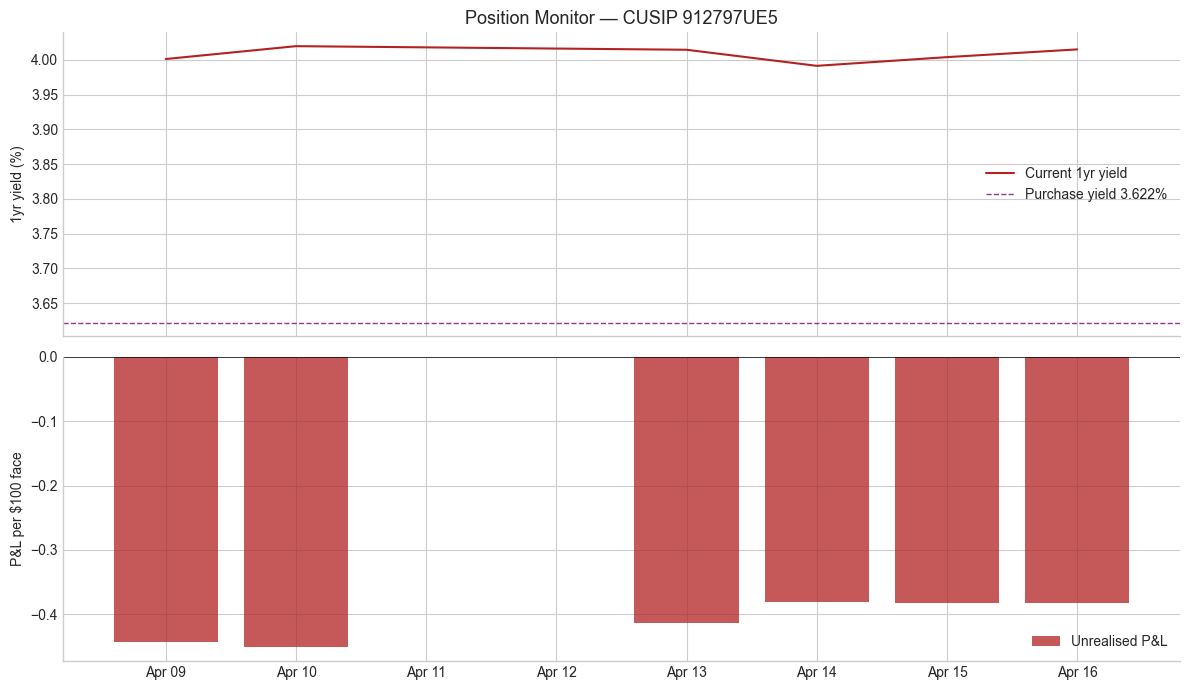

Latest date           : 2026-04-16
Current 1yr yield     : 4.015%
Rate change           : +39.0 bps
Unrealised P&L        : $-0.3829
DV01                  : $0.009625
Modified duration     : 1.002 yrs
Current regime        : Tightening


In [6]:
if len(report) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(report['date'], report['current_yield_pct'],
                 color='firebrick', linewidth=1.5, label='Current 1yr yield')
    axes[0].axhline(PURCHASE_YIELD, color='purple', linewidth=1,
                    linestyle='--', alpha=0.8,
                    label=f'Purchase yield {PURCHASE_YIELD}%')
    axes[0].set_ylabel('1yr yield (%)')
    axes[0].legend()
    axes[0].set_title('Position Monitor — CUSIP 912797UE5', fontsize=13)

    bar_colors = ['firebrick' if v < 0 else 'seagreen'
                  for v in report['unrealised_pnl']]
    axes[1].bar(report['date'], report['unrealised_pnl'],
                color=bar_colors, alpha=0.75, label='Unrealised P&L')
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].set_ylabel('P&L per $100 face')
    axes[1].legend()

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    plt.tight_layout()
    plt.show()

    latest = report.iloc[-1]
    print(f"Latest date           : {latest['date'].date()}")
    print(f"Current 1yr yield     : {latest['current_yield_pct']:.3f}%")
    print(f"Rate change           : {latest['rate_change_bps']:+.1f} bps")
    print(f"Unrealised P&L        : ${latest['unrealised_pnl']:+.4f}")
    print(f"DV01                  : ${latest['dv01']:.6f}")
    print(f"Modified duration     : {latest['modified_duration']:.3f} yrs")
    print(f"Current regime        : {latest['regime_label']}")
else:
    print("Position report empty — check purchase date vs FRED data availability.")

## 6. Scenario analysis

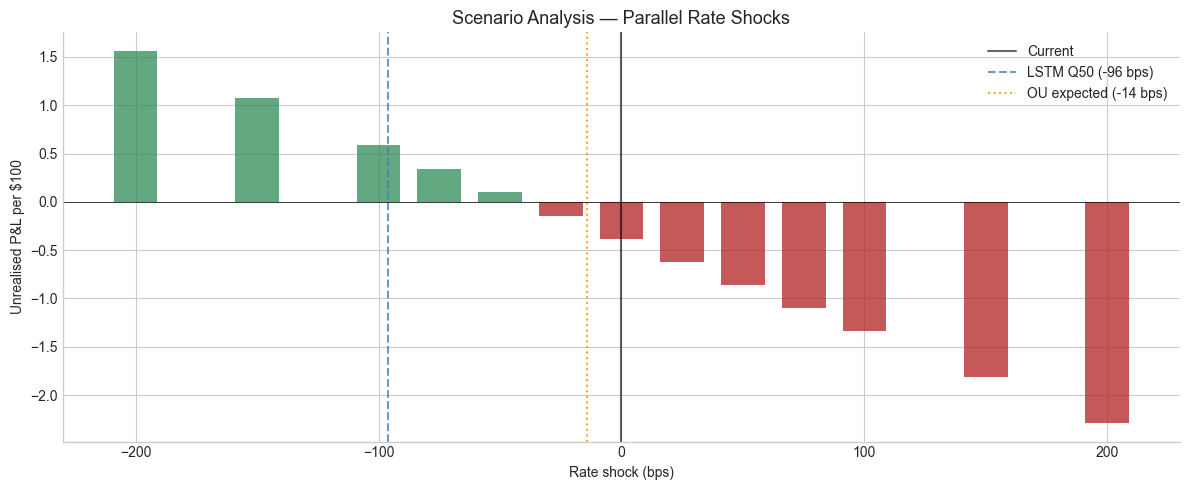

 shock_bps  scenario_yield_pct  implied_price  unrealised_pnl  total_pnl
      -200              2.0149      98.001184        1.561609   1.561609
      -150              2.5149      97.511400        1.071825   1.071825
      -100              3.0149      97.024064        0.584489   0.584489
       -75              3.2649      96.781310        0.341735   0.341735
       -50              3.5149      96.539163        0.099588   0.099588
       -25              3.7649      96.297622       -0.141953  -0.141953
         0              4.0149      96.056686       -0.382889  -0.382889
        25              4.2649      95.816352       -0.623223  -0.623223
        50              4.5149      95.576620       -0.862955  -0.862955
        75              4.7649      95.337487       -1.102088  -1.102088
       100              5.0149      95.098953       -1.340622  -1.340622
       150              5.5149      94.623674       -1.815901  -1.815901
       200              6.0149      94.150770      

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ['firebrick' if v < 0 else 'seagreen'
              for v in scenarios['unrealised_pnl']]
ax.bar(scenarios['shock_bps'], scenarios['unrealised_pnl'],
       color=bar_colors, alpha=0.75, width=18)

ax.axvline(0, color='black', linewidth=1.5, alpha=0.6, label='Current')

if 'lstm_q50' in scenarios.columns and 'scenario_yield_pct' in scenarios.columns:
    current_yield = float(
        scenarios.loc[scenarios['is_current'] == 1, 'scenario_yield_pct'].iloc[0])
    q50_shift = (float(scenarios['lstm_q50'].iloc[0]) - current_yield) * 100
    ou_shift  = (float(scenarios['ou_expected_yield'].iloc[0]) - current_yield) * 100
    ax.axvline(q50_shift, color='steelblue', linewidth=1.5, linestyle='--',
               alpha=0.8, label=f'LSTM Q50 ({q50_shift:+.0f} bps)')
    ax.axvline(ou_shift,  color='darkorange', linewidth=1.5, linestyle=':',
               alpha=0.8, label=f'OU expected ({ou_shift:+.0f} bps)')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Rate shock (bps)')
ax.set_ylabel('Unrealised P&L per $100')
ax.set_title('Scenario Analysis — Parallel Rate Shocks', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(scenarios[['shock_bps','scenario_yield_pct','implied_price',
                  'unrealised_pnl','total_pnl']].to_string(index=False))

## 7. OU vs LSTM divergence

The two models tell different stories at the 252-day horizon.
The OU model forecasts higher rates (tightening regime mean reversion).
The LSTM forecasts lower rates (learned regime transition patterns).
This divergence reflects genuine forecast uncertainty — both are valid.

Forecast Comparison — 252-day horizon
  Purchase yield         : 3.622%

  OU expected yield      : 3.872%  +/- 0.183%
  OU P(rates rise)       : 91.4%

  LSTM Q10               : 2.492%
  LSTM Q50 (central)     : 3.054%
  LSTM Q74 (ZCB-optimal) : 3.340%

  OU-LSTM Q50 divergence : +0.818%


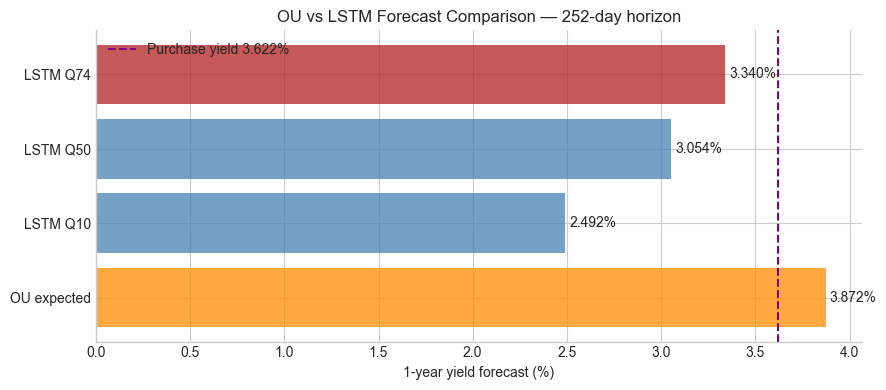

In [8]:
ou_expected = float(pa['expected_yield_pct'].iloc[0])    if len(pa) > 0 else None
ou_std      = float(pa['forecast_std_yield_pct'].iloc[0]) if len(pa) > 0 else None
prob_rise   = float(pa['prob_rate_rise'].iloc[0])         if len(pa) > 0 else None
lstm_q10    = float(fcast_cur['q10'].iloc[0])
lstm_q50    = float(fcast_cur['q50'].iloc[0])
lstm_q74    = float(fcast_cur['q74'].iloc[0])

print("Forecast Comparison — 252-day horizon")
print("=" * 50)
print(f"  Purchase yield         : {PURCHASE_YIELD:.3f}%")
print()
if ou_expected:
    print(f"  OU expected yield      : {ou_expected:.3f}%  +/- {ou_std:.3f}%")
    print(f"  OU P(rates rise)       : {prob_rise:.1%}")
print()
print(f"  LSTM Q10               : {lstm_q10:.3f}%")
print(f"  LSTM Q50 (central)     : {lstm_q50:.3f}%")
print(f"  LSTM Q74 (ZCB-optimal) : {lstm_q74:.3f}%")
if ou_expected:
    print()
    print(f"  OU-LSTM Q50 divergence : {ou_expected - lstm_q50:+.3f}%")

# Visual comparison
fig, ax = plt.subplots(figsize=(9, 4))
models = ['OU expected', 'LSTM Q10', 'LSTM Q50', 'LSTM Q74']
values = [ou_expected, lstm_q10, lstm_q50, lstm_q74]
colors = ['darkorange', 'steelblue', 'steelblue', 'firebrick']

bars = ax.barh(models, values, color=colors, alpha=0.75)
ax.axvline(PURCHASE_YIELD, color='purple', linewidth=1.5,
           linestyle='--', label=f'Purchase yield {PURCHASE_YIELD}%')
ax.bar_label(bars, fmt='%.3f%%', padding=3)
ax.set_xlabel('1-year yield forecast (%)')
ax.set_title('OU vs LSTM Forecast Comparison — 252-day horizon', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()